# Acoustic Pipe Inspection — Live Demo

End-to-end walkthrough: simulate a pipe signal, detect whether a blockage is present, and estimate its position.

No training required — loads the pre-trained models from `outputs/models/`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import torch

from src.simulation import AcousticPipeSimulator, PipeConfig, Blockage
from src.features   import (
    spectrogram_batch, normalise_signals,
    make_pulse, matched_filter_echo_peaks, compute_spectrogram,
)
from src.models import BlockageDetector, BlockageLocaliser

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

FS       = 44_100
PIPE_LEN = 30.0   # metres
DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

# Load pre-trained models
specs_shape = np.load('../outputs/features/spectrograms.npy', mmap_mode='r').shape
_, _, F, T  = specs_shape

detector  = BlockageDetector(freq_bins=F, time_bins=T)
detector.load_state_dict(torch.load('../outputs/models/detector.pth', map_location='cpu'))
detector.eval()

localiser = BlockageLocaliser()
localiser.load_state_dict(torch.load('../outputs/models/localiser.pth', map_location='cpu'))
localiser.eval()

sim = AcousticPipeSimulator(fs=FS, pulse_freq=2_000, pulse_duration=0.003)
pulse_template = make_pulse(fs=FS)

print('Models loaded.')

Using device: cpu
Models loaded.


## Helper: run full inference on a signal

In [2]:
def inspect(signal: np.ndarray, pipe_len: float = PIPE_LEN) -> dict:
    """
    Run detection + localisation on a raw waveform.
    Returns a dict with keys: label, confidence, probs, position_m (or None).
    """
    # Detection
    spec = spectrogram_batch(signal[np.newaxis], fs=FS, nperseg=512,
                             noverlap=384, freq_max=8_000, target_time_bins=T)
    with torch.no_grad():
        logits = detector(torch.tensor(spec))
        probs  = torch.softmax(logits, dim=1).numpy()[0]

    pred  = int(np.argmax(probs))
    label = 'BLOCKED' if pred == 1 else 'CLEAR'

    # Localisation (only if blocked)
    pos_m = None
    if pred == 1:
        sig_norm = normalise_signals(signal[np.newaxis])[0]
        x = torch.tensor(sig_norm[np.newaxis, np.newaxis, :], dtype=torch.float32)
        with torch.no_grad():
            pos_m = localiser(x).item() * pipe_len

    return {'label': label, 'confidence': float(probs[pred]),
            'probs': probs, 'position_m': pos_m}


def plot_result(signal, result, title='', true_pos=None, pipe_len=PIPE_LEN):
    t = np.arange(len(signal)) / FS * 1000   # ms

    # Matched-filter output
    P = len(pulse_template)
    from scipy.signal import correlate
    mf = np.abs(correlate(signal.astype(np.float64),
                          pulse_template.astype(np.float64), mode='full')[P-1:])
    mf = mf / (mf.max() + 1e-12)

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    color = 'crimson' if result['label'] == 'BLOCKED' else 'seagreen'

    # Waveform
    axes[0].plot(t[:int(0.15*FS)], signal[:int(0.15*FS)], lw=0.6, color='steelblue')
    axes[0].set(xlabel='Time (ms)', ylabel='Amplitude', title='Received waveform')
    axes[0].grid(alpha=0.3)

    # Matched filter
    axes[1].plot(t[:int(0.15*FS)], mf[:int(0.15*FS)], lw=0.8, color='darkorange')
    if result['position_m'] is not None:
        echo_t = 2 * result['position_m'] / 343.0 * 1000  # ms
        axes[1].axvline(echo_t, color='crimson', linestyle='--', lw=1.5,
                        label=f'CNN pred: {result["position_m"]:.1f} m')
    if true_pos is not None:
        echo_t_true = 2 * true_pos / 343.0 * 1000
        axes[1].axvline(echo_t_true, color='navy', linestyle=':', lw=1.5,
                        label=f'True: {true_pos:.1f} m')
    axes[1].set(xlabel='Time (ms)', ylabel='Normalised MF output', title='Matched filter')
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)

    # Spectrogram
    _, t_s, Sdb = compute_spectrogram(signal, fs=FS, nperseg=512, noverlap=384, freq_max=8_000)
    axes[2].imshow(Sdb, aspect='auto', origin='lower',
                   extent=[t_s[0]*1000, t_s[-1]*1000, 0, 8],
                   cmap='magma')
    axes[2].set(xlabel='Time (ms)', ylabel='Frequency (kHz)', title='Spectrogram')
    axes[2].set_xlim(0, 150)

    verdict = f"{result['label']}  ({result['confidence']:.0%})"
    if result['position_m'] is not None:
        verdict += f"  |  blockage at {result['position_m']:.1f} m"
    fig.suptitle(f"{title}\n{verdict}",
                 fontsize=12, fontweight='bold', color=color)
    plt.tight_layout()
    plt.show()

print('Helper functions ready.')

Helper functions ready.


## Example 1: Clear pipe

C:\Users\Rohith Syam\AppData\Local\Temp\ipykernel_49312\3340759924.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(fontsize=9)


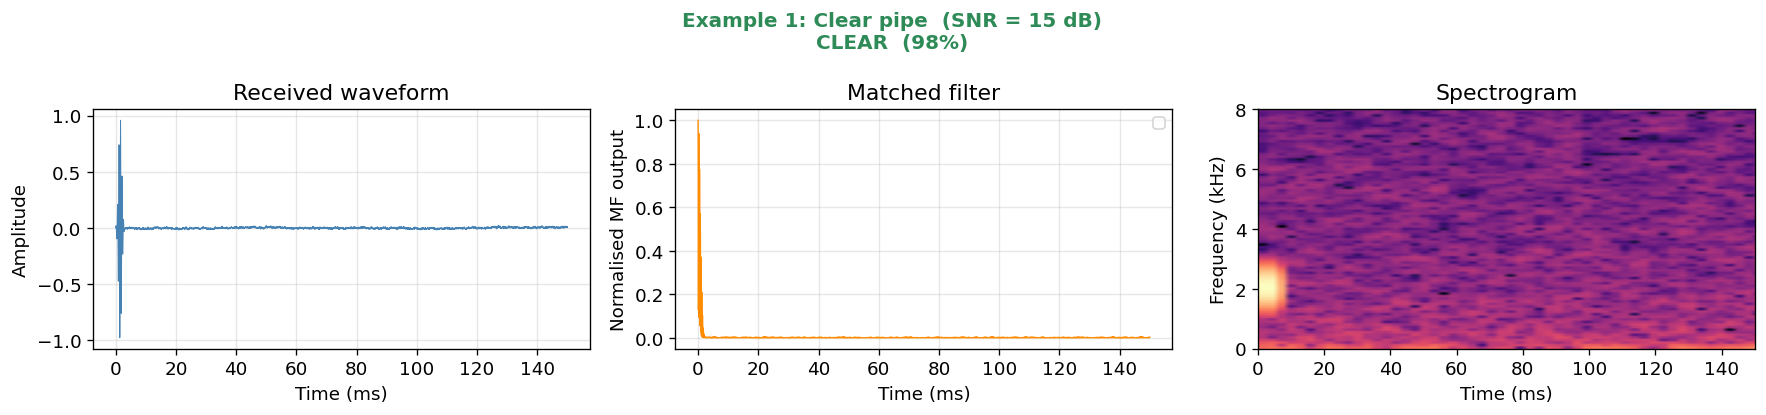

In [3]:
pipe = PipeConfig(length=PIPE_LEN, speed_of_sound=343.0, attenuation_db_m=0.08)

_, sig_clear, _ = sim.simulate(pipe, blockages=[], snr_db=15, signal_duration=0.35)

result_clear = inspect(sig_clear)
plot_result(sig_clear, result_clear, title='Example 1: Clear pipe  (SNR = 15 dB)')

## Example 2: Blocked pipe (known position)

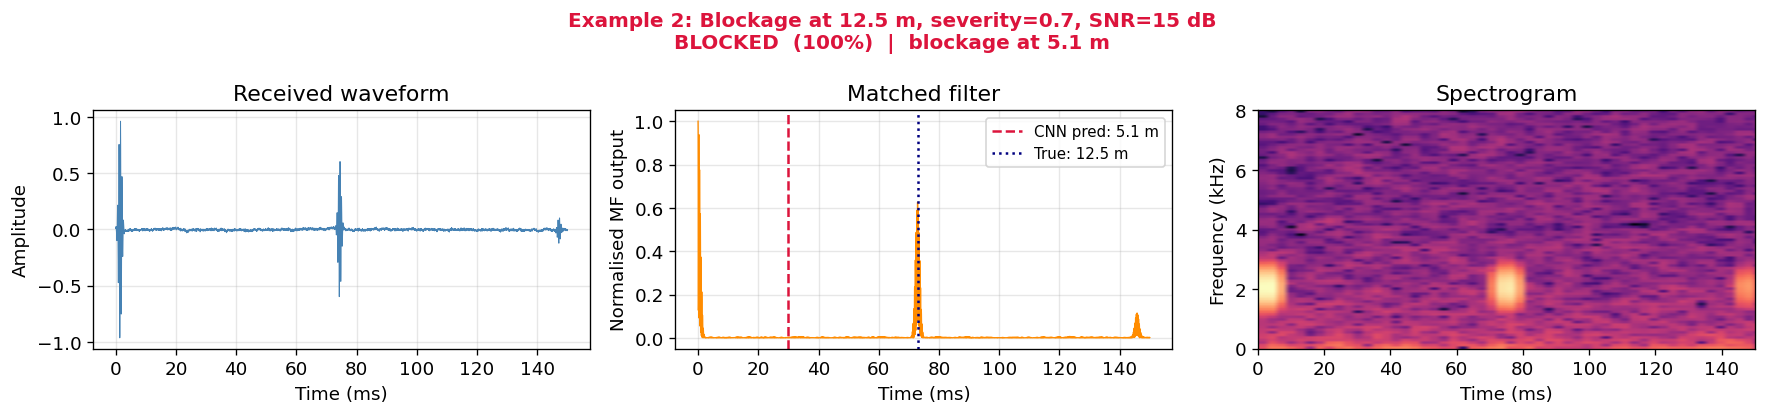

Localisation error: 7.35 m


In [4]:
TRUE_POS  = 12.5   # metres
SEVERITY  = 0.7
SNR       = 15

_, sig_blocked, _ = sim.simulate(
    pipe,
    blockages=[Blockage(position=TRUE_POS, severity=SEVERITY)],
    snr_db=SNR,
    signal_duration=0.35,
)

result_blocked = inspect(sig_blocked)
error = abs(result_blocked['position_m'] - TRUE_POS) if result_blocked['position_m'] else None

plot_result(sig_blocked, result_blocked,
            title=f'Example 2: Blockage at {TRUE_POS} m, severity={SEVERITY}, SNR={SNR} dB',
            true_pos=TRUE_POS)

if error is not None:
    print(f'Localisation error: {error:.2f} m')

## Example 3: Effect of SNR on localisation accuracy

In [5]:
TRUE_POS = 20.0
snr_levels = [5, 10, 15, 20, 25]

rows = []
for snr in snr_levels:
    _, sig, _ = sim.simulate(
        pipe,
        blockages=[Blockage(position=TRUE_POS, severity=0.8)],
        snr_db=snr,
        signal_duration=0.35,
    )
    r = inspect(sig)
    pos = r['position_m'] if r['position_m'] is not None else float('nan')
    err = abs(pos - TRUE_POS) if not np.isnan(pos) else float('nan')
    rows.append((snr, r['label'], r['confidence'], pos, err))
    print(f'SNR={snr:3d} dB  ->  {r["label"]:7s} ({r["confidence"]:.0%})'
          f'  pred={pos:5.1f} m  error={err:.2f} m')

print(f'\nTrue position: {TRUE_POS} m')

SNR=  5 dB  ->  BLOCKED (100%)  pred=  1.7 m  error=18.26 m
SNR= 10 dB  ->  BLOCKED (100%)  pred=  3.3 m  error=16.72 m


SNR= 15 dB  ->  BLOCKED (100%)  pred=  6.3 m  error=13.68 m
SNR= 20 dB  ->  BLOCKED (100%)  pred= 16.0 m  error=3.99 m


SNR= 25 dB  ->  BLOCKED (100%)  pred= 16.1 m  error=3.91 m

True position: 20.0 m


## Example 4: Sweep of blockage positions across the pipe

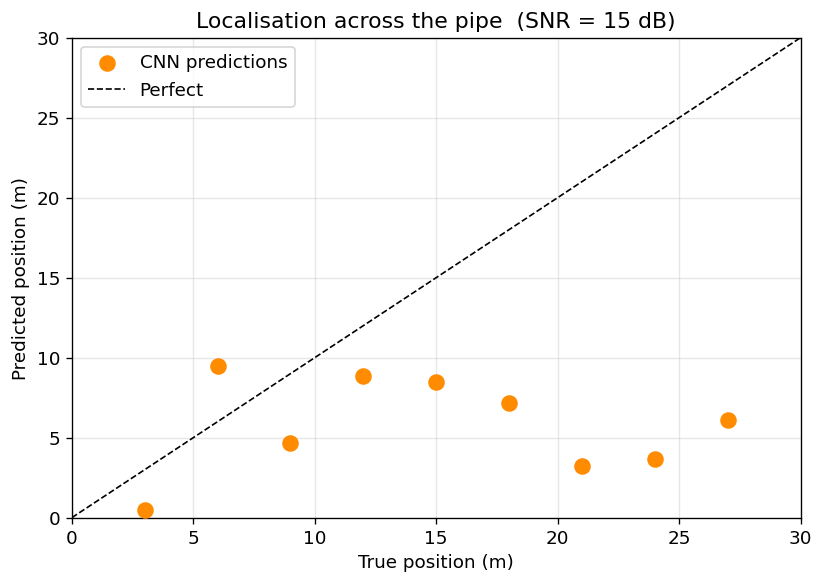

MAE across positions: 9.99 m


In [6]:
positions_true = [3, 6, 9, 12, 15, 18, 21, 24, 27]
positions_pred = []

for pos in positions_true:
    _, sig, _ = sim.simulate(
        pipe,
        blockages=[Blockage(position=pos, severity=0.8)],
        snr_db=15,
        signal_duration=0.35,
    )
    r = inspect(sig)
    pred_pos = r['position_m'] if r['position_m'] is not None else np.nan
    positions_pred.append(pred_pos)

positions_pred = np.array(positions_pred)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(positions_true, positions_pred, s=80, color='darkorange', zorder=3, label='CNN predictions')
ax.plot([0, PIPE_LEN], [0, PIPE_LEN], 'k--', lw=1, label='Perfect')
ax.set(xlabel='True position (m)', ylabel='Predicted position (m)',
       title='Localisation across the pipe  (SNR = 15 dB)',
       xlim=(0, PIPE_LEN), ylim=(0, PIPE_LEN))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

mae = np.nanmean(np.abs(positions_pred - np.array(positions_true)))
print(f'MAE across positions: {mae:.2f} m')

## Example 5: Side-by-side comparison — clear vs blocked

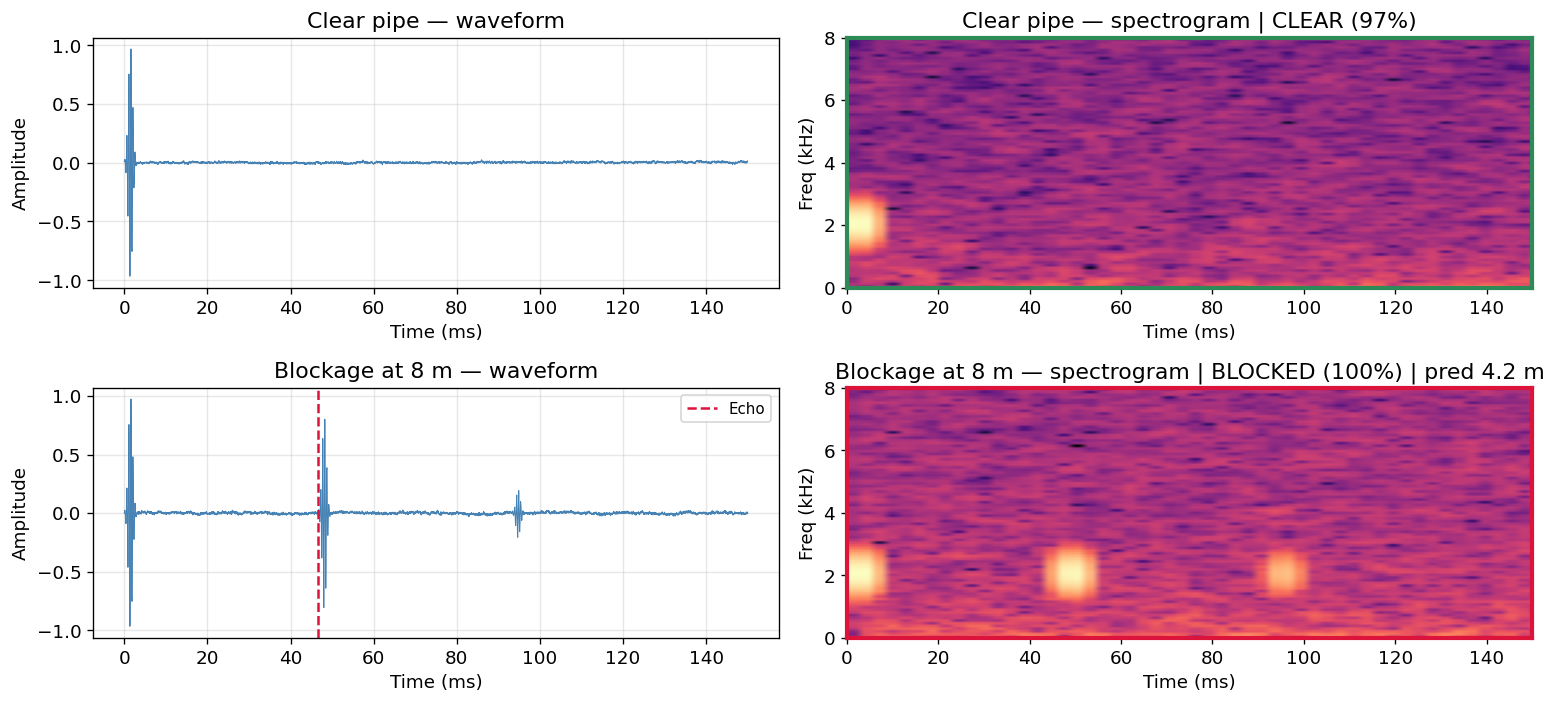

In [7]:
_, sig_a, _ = sim.simulate(pipe, blockages=[], snr_db=15, signal_duration=0.35)
_, sig_b, _ = sim.simulate(pipe, [Blockage(8.0, 0.9)], snr_db=15, signal_duration=0.35)

t = np.arange(int(0.15 * FS)) / FS * 1000

fig, axes = plt.subplots(2, 2, figsize=(13, 6))

for row, (sig, label, true_p) in enumerate([
        (sig_a, 'Clear pipe',       None),
        (sig_b, 'Blockage at 8 m',  8.0),
]):
    r = inspect(sig)
    color = 'crimson' if r['label'] == 'BLOCKED' else 'seagreen'

    # Waveform
    axes[row, 0].plot(t, sig[:len(t)], lw=0.6, color='steelblue')
    if true_p is not None:
        echo_t = 2 * true_p / 343.0 * 1000
        axes[row, 0].axvline(echo_t, color='crimson', linestyle='--', lw=1.5, label='Echo')
        axes[row, 0].legend(fontsize=9)
    axes[row, 0].set(xlabel='Time (ms)', ylabel='Amplitude',
                     title=f'{label} — waveform')
    axes[row, 0].grid(alpha=0.3)

    # Spectrogram
    _, t_s, Sdb = compute_spectrogram(sig, fs=FS, nperseg=512, noverlap=384, freq_max=8_000)
    axes[row, 1].imshow(Sdb, aspect='auto', origin='lower',
                        extent=[t_s[0]*1000, t_s[-1]*1000, 0, 8],
                        cmap='magma')
    verdict = f"{r['label']} ({r['confidence']:.0%})"
    if r['position_m'] is not None:
        verdict += f" | pred {r['position_m']:.1f} m"
    axes[row, 1].set(xlabel='Time (ms)', ylabel='Freq (kHz)',
                     title=f'{label} — spectrogram | {verdict}')
    axes[row, 1].set_xlim(0, 150)
    for sp in axes[row, 1].spines.values():
        sp.set_edgecolor(color)
        sp.set_linewidth(2.5)

plt.tight_layout()
plt.show()

## Example 6: Batch inference on 20 random test signals

In [8]:
np.random.seed(99)
N = 20
results_table = []

for i in range(N):
    is_blocked = np.random.rand() > 0.5
    true_pos   = np.random.uniform(3, 27) if is_blocked else None

    bkgs = [Blockage(true_pos, severity=np.random.uniform(0.5, 1.0))] if is_blocked else []
    _, sig, _ = sim.simulate(pipe, bkgs, snr_db=np.random.uniform(8, 20),
                             signal_duration=0.35)
    r = inspect(sig)

    true_label = 'BLOCKED' if is_blocked else 'CLEAR'
    correct    = (r['label'] == true_label)
    loc_err    = abs(r['position_m'] - true_pos) if (is_blocked and r['position_m']) else None

    results_table.append({
        'true': true_label,
        'pred': r['label'],
        'conf': r['confidence'],
        'true_pos': true_pos,
        'pred_pos': r['position_m'],
        'correct': correct,
        'loc_err': loc_err,
    })

# Print summary table
print(f'{"#":>2}  {"True":8} {"Pred":8} {"Conf":6}  {"True pos":9} {"Pred pos":9}  {"Loc err":8}  OK')
print('-' * 70)
for i, r in enumerate(results_table):
    tp = f'{r["true_pos"]:.1f} m' if r['true_pos'] else '  -  '
    pp = f'{r["pred_pos"]:.1f} m' if r['pred_pos'] else '  -  '
    le = f'{r["loc_err"]:.2f} m' if r['loc_err'] is not None else '  -  '
    ok = 'Y' if r['correct'] else 'N'
    print(f'{i+1:2d}  {r["true"]:8} {r["pred"]:8} {r["conf"]:.0%}    {tp:9} {pp:9}  {le:8}  {ok}')

n_correct = sum(r['correct'] for r in results_table)
loc_errs  = [r['loc_err'] for r in results_table if r['loc_err'] is not None]
print(f'\nDetection accuracy : {n_correct}/{N} ({n_correct/N:.0%})')
if loc_errs:
    print(f'Mean localisation error (blocked, correct detections): {np.mean(loc_errs):.2f} m')

 #  True     Pred     Conf    True pos  Pred pos   Loc err   OK
----------------------------------------------------------------------
 1  BLOCKED  BLOCKED  100%    14.7 m    29.5 m     14.81 m   Y
 2  CLEAR    CLEAR    89%      -         -          -       Y
 3  CLEAR    CLEAR    96%      -         -          -       Y
 4  CLEAR    CLEAR    94%      -         -          -       Y
 5  BLOCKED  BLOCKED  100%    19.0 m    5.0 m      14.00 m   Y
 6  BLOCKED  BLOCKED  100%    12.7 m    8.5 m      4.16 m    Y
 7  BLOCKED  BLOCKED  100%    21.2 m    13.2 m     8.01 m    Y
 8  BLOCKED  BLOCKED  100%    18.8 m    9.8 m      9.08 m    Y
 9  BLOCKED  BLOCKED  97%    26.4 m    11.0 m     15.41 m   Y
10  CLEAR    CLEAR    96%      -         -          -       Y
11  BLOCKED  BLOCKED  99%    3.9 m     0.3 m      3.53 m    Y
12  BLOCKED  BLOCKED  99%    23.5 m    7.6 m      15.94 m   Y
13  BLOCKED  BLOCKED  100%    12.6 m    1.5 m      11.13 m   Y
14  BLOCKED  BLOCKED  99%    3.5 m     1.1 m      2.4